# Mueller Matrix Microscope

In [1]:
from mpl_toolkits.axes_grid1.anchored_artists import AnchoredSizeBar
from scipy.ndimage import gaussian_filter, laplace
from scipy.linalg import sqrtm
from skimage.exposure import match_histograms
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib.colors as mcolors
import matplotlib.ticker as ticker
import numpy as np
import imageio
import cv2
import scipy
import gzip
import time
import glob
import natsort
import os
import ipywidgets as widgets
from IPython.display import display

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


#Funciones

In [4]:
MAX16 = 2**16-1
MAX8 = 2**8-1

def lu_chipman_3x4(M):
  #Identidades
  I2 = np.stack([np.stack([np.identity(2)]*M.shape[1])]*M.shape[0])
  I3 = np.stack([np.stack([np.identity(3)]*M.shape[1])]*M.shape[0])

  #Normalización
  M_norm = M.copy()
  for i in range(3):
    for j in range(4):
      M_norm[:,:,i,j] = M[:,:,i,j]/M[:,:,0,0]

  #M Diatenuación
  MD = np.ones((M.shape[0],M.shape[1],4,4))
  MD_inv = np.ones_like(M)
  D = M_norm[:,:,0,1:]
  D2 = np.einsum('ijk,ijk->ij',D, D)
  a = np.sqrt(1-D2,out=np.zeros_like(D2),where=D2<=1)
  b = np.divide(1-a,D2,out=np.zeros_like(D2),where=D2!=0)
  MD[:,:,0,1:] = D
  MD[:,:,1:,0] = D
  for i in range(3):
    for j in range(3):
      MD[:,:,1+i,1+j] = a*I3[:,:,i,j] + b*np.einsum('ijk,ijl->ijkl',D,D)[:,:,i,j]

  #M Prima
  Mprima = np.einsum('ijkl,ijlm->ijkm',M_norm[:,:,:,:],np.linalg.pinv(MD[:,:,:,:]))
  mprima = Mprima[:,:,1:,1:]

  #M Delta
  mdr = np.einsum('ijkl,ijlm->ijkm', mprima, mprima.transpose(0,1,3,2))
  L, V = np.linalg.eig(mdr)
  L_sqrt_diag = np.zeros((M.shape[0],M.shape[1],2,2))
  L[L < 0] = 0.01
  L_sqrt_diag[:,:,0,0] = np.sqrt(L[:,:,0])
  L_sqrt_diag[:,:,1,1] = np.sqrt(L[:,:,1])
  mdr_sqrt = np.einsum('ijkl,ijlm->ijkm', V, L_sqrt_diag)
  mdr_sqrt = np.einsum('ijkl,ijlm->ijkm', mdr_sqrt, V.transpose(0,1,3,2))
  MDelta = np.zeros((M.shape[0],M.shape[1],3,3))
  MDelta[:,:,0,0] = 1
  MDelta[:,:,1:,1:] = mdr_sqrt

  #Polarizancia:
  PDelta = np.zeros((M.shape[0],M.shape[1],2))
  for i in range(2):
    PDelta[:,:,i] = (M_norm[:,:,1+i,0] - np.einsum('ijkl,ijl->ijk', M_norm[:,:,1:,1:], D)[:,:,i]) / (1 - D2)
  MDelta[:,:,1:,0] = PDelta

  #M Retardancia
  MR = np.einsum('ijkl,ijlm->ijkm', np.linalg.pinv(MDelta), Mprima)

  return MDelta, MR, MD, M[:,:,0,0]

def lu_chipman_batched(M, batch_size=2000):
    N = M.shape[0]
    MDelta_all = []
    MR_all = []
    MD_all = []

    for i in range(0, N, batch_size):
        batch = M[i:i+batch_size]
        MDelta, MR, MD, _ = lu_chipman_3x4(batch)

        MDelta_all.append(MDelta)
        MR_all.append(MR)
        MD_all.append(MD)

    return (
        np.concatenate(MDelta_all, axis=0),
        np.concatenate(MR_all, axis=0),
        np.concatenate(MD_all, axis=0),
    )

def normalizar_mueller(M):
    M_norm = M.copy()
    K, m, n = M.shape[2], M.shape[3], M.shape[4]
    for i in range(m):
        for j in range(n):
            for k in range(K):
                M_norm[:,:,k,i,j] = np.divide(
                    M_norm[:,:,k,i,j],
                    M[:,:,k,0,0],
                    out=np.zeros_like(M_norm[:,:,k,i,j]),
                    where=M[:,:,k,0,0] != 0
                )
    return M_norm, M[:,:,:,0,0]

def bayer_interpolacion_vecinos(M):
  I = np.zeros((M.shape[0],M.shape[1],3), dtype=np.uint16)
  #Rojos R
  I[0::2,0::2,2] = M[0::2,0::2]
  I[0::2,1::2,2] = M[0::2,0::2]
  I[1::2,0::2,2] = M[0::2,0::2]
  I[1::2,1::2,2] = M[0::2,0::2]
  #Verdes G
  I[0::2,0::2,1] = M[1::2,0::2]
  I[1::2,1::2,1] = M[1::2,0::2]
  I[1::2,0::2,1] = M[1::2,0::2]
  I[0::2,1::2,1] = M[0::2,1::2]
  #Azules B
  I[0::2,0::2,0] = M[1::2,1::2]
  I[1::2,0::2,0] = M[1::2,1::2]
  I[0::2,1::2,0] = M[1::2,1::2]
  I[1::2,1::2,0] = M[1::2,1::2]
  return I

def bayer_interpolacion_bilineal(M):
    I = np.zeros((M.shape[0], M.shape[1], 3), dtype=np.float32)

    # Kernel bilineal
    F = (1/4)*np.array([[1,2,1],[2,4,2],[1,2,1]], dtype=np.float32)

    # --- ROJO ---
    R = np.zeros_like(M, dtype=np.float32)
    R[0::2, 0::2] = M[0::2, 0::2]

    mask_R = (R > 0).astype(np.float32)

    R_interp = cv2.filter2D(R, -1, F, borderType=cv2.BORDER_REPLICATE)
    norm_R = cv2.filter2D(mask_R, -1, F, borderType=cv2.BORDER_REPLICATE)
    R_interp /= (norm_R + 1e-8)

    # --- VERDE ---
    G = np.zeros_like(M, dtype=np.float32)
    G[0::2, 1::2] = M[0::2, 1::2]
    G[1::2, 0::2] = M[1::2, 0::2]

    mask_G = (G > 0).astype(np.float32)

    G_interp = cv2.filter2D(G, -1, F, borderType=cv2.BORDER_REPLICATE)
    norm_G = cv2.filter2D(mask_G, -1, F, borderType=cv2.BORDER_REPLICATE)
    G_interp /= (norm_G + 1e-8)

    # --- AZUL ---
    B = np.zeros_like(M, dtype=np.float32)
    B[1::2, 1::2] = M[1::2, 1::2]

    mask_B = (B > 0).astype(np.float32)

    B_interp = cv2.filter2D(B, -1, F, borderType=cv2.BORDER_REPLICATE)
    norm_B = cv2.filter2D(mask_B, -1, F, borderType=cv2.BORDER_REPLICATE)
    B_interp /= (norm_B + 1e-8)

    # Stack final (BGR)
    I[:,:,0] = B_interp
    I[:,:,1] = G_interp
    I[:,:,2] = R_interp

    return I.astype(np.uint16)

def polarization_full_dec_array(A, interpolacion='vecinos'):

    if interpolacion == 'vecinos':
        interp = bayer_interpolacion_vecinos

    elif interpolacion == 'bilineal':
        interp = bayer_interpolacion_bilineal

    else:
        raise ValueError("Interpolación no válida")

    # Descomposición + interpolación
    I0   = interp(A[1::2,1::2])
    I45  = interp(A[0::2,1::2])
    I90  = interp(A[0::2,0::2])
    I135 = interp(A[1::2,0::2])

    return I90, I45, I135, I0

def generate_input_image(I_0, I_45, I_90, I_135):
    height, width, channels = I_0.shape
    I_PFA = np.zeros((2 * height, 2 * width, channels), dtype=np.uint16)
    for i in range(height):
        for j in range(width):
            I_PFA[2*i    , 2*j    ] =   I_0[i, j]
            I_PFA[2*i    , 2*j + 1] =  I_45[i, j]
            I_PFA[2*i + 1, 2*j    ] = I_135[i, j]
            I_PFA[2*i + 1, 2*j + 1] =  I_90[i, j]
    return I_PFA

def convert_to_uint16(I):
    return np.clip(np.round(I), 0, 2**16-1).astype(np.uint16)

def get_polarization_mask(img_shape ,angle):
  if angle not in [0, 45, 90, 135]:
    raise ValueError(
      f'El ángulo de polarizacion debe ser 0°, 45°, 90° o 135°. El valor recibido es {angle=}')
  mask = np.zeros(img_shape)
  if angle == 0:
    mask[::2, ::2] = 1
  elif angle == 45:
    mask[::2, 1::2] = 1
  elif angle == 90:
    mask[1::2, 1::2] = 1
  elif angle == 135:
    mask[1::2, ::2] = 1
  return mask

def quick_bilinear_interpolation(I):
  F = (1/4)*np.array([[1,2,1],[2,4,2],[1,2,1]])
  I_out = cv2.filter2D(I, ddepth=-1, kernel=F, borderType=cv2.BORDER_REPLICATE)
  return I_out

def get_fusion_weight(angle_i, angle_j):
  if angle_i not in [0, 45, 90, 135] or angle_j not in [0, 45, 90, 135]:
        raise ValueError(
            "Los ángulos de polarizacion debe ser 0°, 45°, 90°, o 135°.\n"
            f"Los valores recibidos son {angle_i=}, {angle_j=}."
        )
  if np.abs(angle_i - angle_j) != 90:
    weight = 1 / (2 + np.sqrt(2))
  else:
    weight = np.sqrt(2) / (2 + np.sqrt(2))
  return weight

def reconstruct_polarized_images(I_PFA):
    M = {
        0: get_polarization_mask(I_PFA.shape, 0),
        45: get_polarization_mask(I_PFA.shape, 45),
        90: get_polarization_mask(I_PFA.shape, 90),
        135: get_polarization_mask(I_PFA.shape, 135)
    }
    I_hat = {
        0: I_PFA * M[0],
        45: I_PFA * M[45],
        90: I_PFA * M[90],
        135: I_PFA * M[135]
    }
    I_tilde = {
        0: quick_bilinear_interpolation(I_hat[0]),
        45: quick_bilinear_interpolation(I_hat[45]),
        90: quick_bilinear_interpolation(I_hat[90]),
        135: quick_bilinear_interpolation(I_hat[135])
    }

    polarized_images = []
    for i in [0, 45, 90, 135]:
        complementary_angles = [0, 45, 90, 135]
        complementary_angles.remove(i)
        I_i = np.zeros(I_PFA.shape)
        for j in complementary_angles:
            delta_hat = quick_bilinear_interpolation(I_hat[i] - (I_tilde[j] * M[i]))
            I_i += get_fusion_weight(i, j) * (I_tilde[j] + delta_hat)

        # Igualar histograma con el correspondiente I_tilde[i]
        # I_i = match_histograms(I_i, I_tilde[i], channel_axis=None)

        polarized_images.append(I_i)

    return tuple(polarized_images)

def cargar_intensidades(path, muestra, interpolacion = 'vecinos', rec = False):
  I = np.zeros((1024,1224,3,4,4), dtype = np.uint16)
  I[:,:,:,2,0], I[:,:,:,1,0], I[:,:,:,3,0], I[:,:,:,0,0] = polarization_full_dec_array(cv2.imread(path + muestra + '/' + '0_0.png', -1), interpolacion = interpolacion)
  I[:,:,:,2,1], I[:,:,:,1,1], I[:,:,:,3,1], I[:,:,:,0,1] = polarization_full_dec_array(cv2.imread(path + muestra + '/' + '45_45.png', -1), interpolacion = interpolacion)
  I[:,:,:,2,2], I[:,:,:,1,2], I[:,:,:,3,2], I[:,:,:,0,2] = polarization_full_dec_array(cv2.imread(path + muestra + '/' + '90_90.png', -1), interpolacion = interpolacion)
  I[:,:,:,2,3], I[:,:,:,1,3], I[:,:,:,3,3], I[:,:,:,0,3] = polarization_full_dec_array(cv2.imread(path + muestra + '/' + '135_90.png', -1), interpolacion = interpolacion)

  if rec:
    I_rec = np.zeros((2048,2448,3,4,4), dtype = np.uint16)
    for i in range(4):
      I_PFA = generate_input_image(I[:,:,:,0,i], I[:,:,:,1,i], I[:,:,:,2,i], I[:,:,:,3,i])
      I_0_rec, I_45_rec, I_90_rec, I_135_rec = reconstruct_polarized_images(I_PFA)
      I_rec[:,:,:,2,i], I_rec[:,:,:,1,i], I_rec[:,:,:,3,i], I_rec[:,:,:,0,i] = I_0_rec, I_45_rec, I_90_rec, I_135_rec
    I = I_rec

  return I

def mueller_polarizador(T,D,theta_d):
  theta_d = theta_d*np.pi/180 #Radianes
  MR = np.array([[1,0,0,0],[0,np.cos(2*theta_d),np.sin(2*theta_d),0],[0,-np.sin(2*theta_d),np.cos(2*theta_d),0],[0,0,0,1]])
  M = MR.T @ np.array([[1,D,0,0],[D,1,0,0],[0,0,np.sqrt(1-D**2),0],[0,0,0,np.sqrt(1-D**2)]]) @ MR
  return M
def mueller_retardador(phi,theta):
  theta = theta*np.pi/180   #Radianes
  phi = phi*np.pi/180       #Radianes
  MR = np.array([[1,0,0,0],[0,np.cos(2*theta),np.sin(2*theta),0],[0,-np.sin(2*theta),np.cos(2*theta),0],[0,0,0,1]])
  M =  MR.T @ np.array([[1,0,0,0],[0,1,0,0],[0,0,np.cos(phi),np.sin(phi)],[0,0,-np.sin(phi),np.cos(phi)]]) @ MR
  return M
def mueller_rotador(theta):
  theta = theta*np.pi/180 #Radianes
  M = np.array([[1,0,0,0],[0,np.cos(2*theta),-np.sin(2*theta),0],[0,np.sin(2*theta),np.cos(2*theta),0],[0,0,0,1]])
  return M
def mueller_despolarizador(delta):
  M = np.array([[1,0,0,0],[0,delta,0,0],[0,0,delta,0],[0,0,0,delta]])
  return M
def arctan3(y,x):
  return np.mod(np.arctan2(y,x),2*np.pi)
def calcular_dolp(S0,S1,S2):
  dolp = np.divide(np.sqrt(np.power(S1.astype(float),2) + np.power(S2.astype(float),2)),S0, out = np.zeros_like(S0.astype(float)), where = S0!= 0)
  return dolp
def calcular_aolp(S1,S2):
  aolp = 1/2*np.arctan2(S2.astype(float),S1.astype(float))
  return aolp
def calcular_dolp_mueller(M):
  S0 = M[:,:,0,0];   S1 = M[:,:,1,0];   S2 = M[:,:,2,0]
  return calcular_dolp(S0,S1,S2)
def calcular_aolp_mueller(M):
  S1 = M[:,:,1,0];   S2 = M[:,:,2,0]
  return calcular_aolp(S1,S2)
def calcular_diatenuacion(M):
  D = np.sqrt(M[:,:,0,1]**2+M[:,:,0,2]**2+M[:,:,0,3]**2)/M[:,:,0,0]
  return D
def calcular_diatenuacion_lineal(M):
  D = np.sqrt(M[:,:,0,1]**2+M[:,:,0,2]**2)/M[:,:,0,0]
  return D
def calcular_aod(M):
  S1 = M[:,:,0,1];   S2 = M[:,:,0,2]
  return calcular_aolp(S1,S2)
def power_of_depolarization(M_delta):
  delta = np.ones((M_delta.shape[0],M_delta.shape[1]))-(np.trace(M_delta, axis1=-2, axis2=-1))/M_delta.shape[-1]
  return delta
def optical_activity(M_R):
  psi = 1/2 * np.arctan2(M_R[:,:,2,1]-M_R[:,:,1,2],M_R[:,:,1,1]+M_R[:,:,2,2])
  return psi
def linear_retardance(M_R):
  delta = np.arccos(np.clip(np.sqrt(np.maximum((M_R[:,:,1,1]+M_R[:,:,2,2])**2 + (M_R[:,:,2,1]-M_R[:,:,1,2])**2, 0)) - 1, -1, 1))
  return delta
def optical_axis(MR):
  theta = 0.5 * np.arctan2(-MR[:,:,1,3], MR[:,:,2,3])
  return theta

def sharpener(src, alpha):
  out = (src-alpha*laplace(src)).astype(np.uint16)
  return out

def calcular_mueller_inv(S_in_stat_inv,S_out_stat):
  M = np.einsum('ijklm,ijkmn->ijkln',S_out_stat,S_in_stat_inv)
  return M

def calcular_stokes (I90, I45, I135, I0, A = None, decimador = 1):

  #Decimador
  I0 = I0[::decimador,::decimador]
  I45 = I45[::decimador,::decimador]
  I90 = I90[::decimador,::decimador]
  I135 = I135[::decimador,::decimador]

  #Modo sin calibración
  if A == None:

    #Calculo
    S0 = I0.astype(np.int32)+I90.astype(np.int32)
    S1 = I0.astype(np.int32)-I90.astype(np.int32)
    S2 = I45.astype(np.int32)-I135.astype(np.int32)

  #Modo calibrado
  else:

    #Decimador
    A = A[::decimador,::decimador]
    A = A[::decimador,::decimador]
    A = A[::decimador,::decimador]
    A = A[::decimador,::decimador]

    #Calculo
    S0 = A[:,:,:,0,0]*I0.astype(float)+A[:,:,:,0,1]*I45.astype(float)+A[:,:,:,0,2]*I90.astype(float)+A[:,:,:,0,3]*I135.astype(float)
    S1 = A[:,:,:,1,0]*I0.astype(float)+A[:,:,:,1,1]*I45.astype(float)+A[:,:,:,1,2]*I90.astype(float)+A[:,:,:,1,3]*I135.astype(float)
    S2 = A[:,:,:,2,0]*I0.astype(float)+A[:,:,:,2,1]*I45.astype(float)+A[:,:,:,2,2]*I90.astype(float)+A[:,:,:,2,3]*I135.astype(float)

  #Resultado
  stokes = [S0, S1, S2]

  return stokes

def calcular_S3(S_in, signo_global = -1, signo_ultimo = +1):
    # Cálculo base (en float para evitar overflow)
    S3 = np.sqrt(S_in[:,:,:,0,:].astype(float)**2 - S_in[:,:,:,1,:].astype(float)**2 - S_in[:,:,:,2,:].astype(float)**2).astype(np.int32)

    # Aplicar signos
    S_in[:,:,:,3,0:3] = signo_global * S3[:,:,:,0:3]
    S_in[:,:,:,3,3] = signo_ultimo * S3[:,:,:,3]

    return S_in

def acoplar_matriz(M):
    # Número de filas de la matriz M
    filas = M.shape[3]  # M[:,:,:,i,j] -> i va hasta shape[3]
    N = M.shape[4]      # Número de columnas -> shape[4]

    # Crear una lista para almacenar las matrices acopladas horizontalmente
    matrices_acopladas = []

    # Acoplar horizontalmente cada matriz individual
    for i in range(filas):
        matriz_i = M[:,:,:,i,0].copy()
        for j in range(1, N):
            matriz_i = np.append(matriz_i, M[:,:,:,i,j], axis=1)
        matrices_acopladas.append(matriz_i)

    # Acoplar verticalmente todas las matrices acopladas horizontalmente
    M_show = np.concatenate(matrices_acopladas, axis=0)

    return M_show

def desacoplar_matriz(A_show, dim = (1024,1224)):

  #Numero de Vectores
  M = A_show.shape[0]//dim[0]

  #Numero de Vectores
  N = A_show.shape[1]//dim[1]

  K = A_show.shape[2]

  #Matriz de Mueller
  A = np.zeros((dim[0],dim[1],K,M,N), dtype=float)

  #Desacoplado
  for i in range(M):
    for j in range(N):
      for k in range(K):
        A[:,:,k,i,j] = A_show[i*dim[0]:(i+1)*dim[0],j*dim[1]:(j+1)*dim[1],k]

  return A

# Mueller Microscopy

In [49]:
# Ruta
base_path = "/content/drive/MyDrive/Colab/Mueller/dataset/3x4" # Change directory

# Leer subcarpetas
muestras = sorted([d for d in os.listdir(base_path) if os.path.isdir(os.path.join(base_path, d))])

# Crear dropdowns
#dropdown_input = widgets.Dropdown(options=muestras,value=muestras[0],description='Input:',)
#dropdown_output = widgets.Dropdown(options=muestras,value=muestras[0],description='Output:',)
#display(dropdown_input, dropdown_output)

In [32]:
# Parámetros
signo_global = -1
rec = False
interpolacion = 'bilineal'
py, px, c = 0,0,0
signo_ultimo = 1            # ELEGIR

# Muestras
muestra_input = dropdown_input.value
muestra_output = dropdown_output.value
muestra_path = "/content/drive/MyDrive/Colab/Mueller/dataset/3x4/"

# Imagenes salida
I_out = cargar_intensidades(muestra_path, muestra_output, interpolacion = interpolacion, rec = rec)

# Imagenes entrada
I_in = cargar_intensidades(muestra_path, muestra_input, interpolacion = interpolacion, rec = False)
I_in = np.broadcast_to(I_in[px, py, c, :, :][None, None, None, :, :],(2048,2448,3,4,4) if rec else (1024,1224,3,4,4)).copy()

# Stokes input
S_in = np.zeros((2048,2448,3,4,4) if rec else (1024,1224,3,4,4), dtype=float)
S_in[:,:,:,0,:], S_in[:,:,:,1,:], S_in[:,:,:,2,:] = calcular_stokes(I_in[:,:,:,2,:], I_in[:,:,:,1,:], I_in[:,:,:,3,:], I_in[:,:,:,0,:])

# Calcular S3
S_in = calcular_S3(S_in, signo_global = signo_global, signo_ultimo = signo_ultimo)

# Stokes ouput
S_out = np.zeros((2048,2448,3,3,4) if rec else (1024,1224,3,3,4), dtype=float)
S_out[:,:,:,0,:], S_out[:,:,:,1,:], S_out[:,:,:,2,:] = calcular_stokes(I_out[:,:,:,2,:], I_out[:,:,:,1,:], I_out[:,:,:,3,:], I_out[:,:,:,0,:])

# Número de condición
S_in_00 = S_in[px,py,c,:,:]
S_in_inv_00 = np.linalg.pinv(S_in_00)
print("Matriz de entrada: \n", S_in_00)
print(f"\nNúmero de condición: \n {np.linalg.cond(S_in_00):.1f}")

# Matriz de entrada imagen
S_in_inv = np.zeros((2048,2448,3,4,4) if rec else (1024,1224,3,4,4), dtype=float)
S_in_inv[:, :, :, :, :] = S_in_inv_00[np.newaxis, np.newaxis, np.newaxis, :, :]

#Calculo de Mueller
M = np.einsum('ijklm,ijkmn->ijkln', S_out, S_in_inv)
M_norm, m00 = normalizar_mueller(M)

# Liberar variables
# del S_in, S_in_inv, S_out, M

Matriz de entrada: 
 [[ 37013.  39297.  36083.  38208.]
 [-30987. -13469.  28447.  -6038.]
 [-12830.  31195.  14828.  -1593.]
 [-15657. -19741. -16519.  37694.]]

Número de condición: 
 3.3


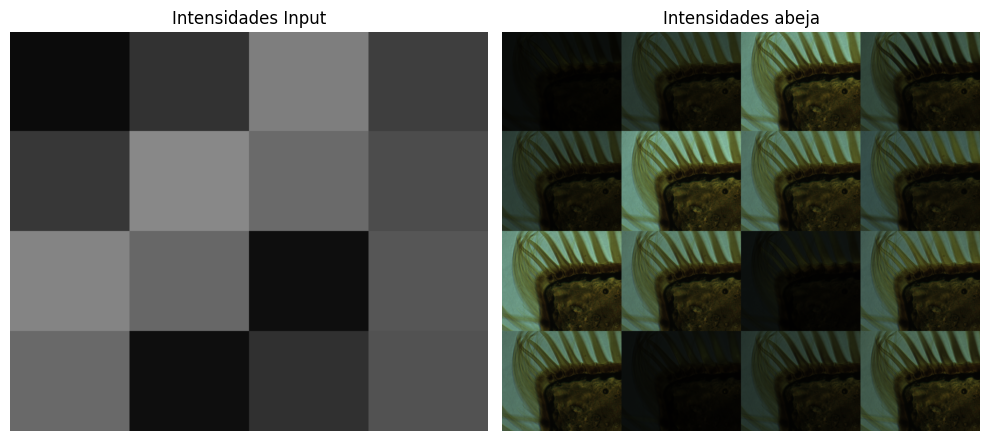

In [50]:
# Figuras
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(cv2.cvtColor(acoplar_matriz(I_in)//2**8, cv2.COLOR_RGB2BGR))
plt.title('Intensidades Input')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(cv2.cvtColor(acoplar_matriz(I_out)//2**8, cv2.COLOR_RGB2BGR))
plt.title('Intensidades ' + muestra_output)
plt.axis('off')

plt.tight_layout()
plt.show()

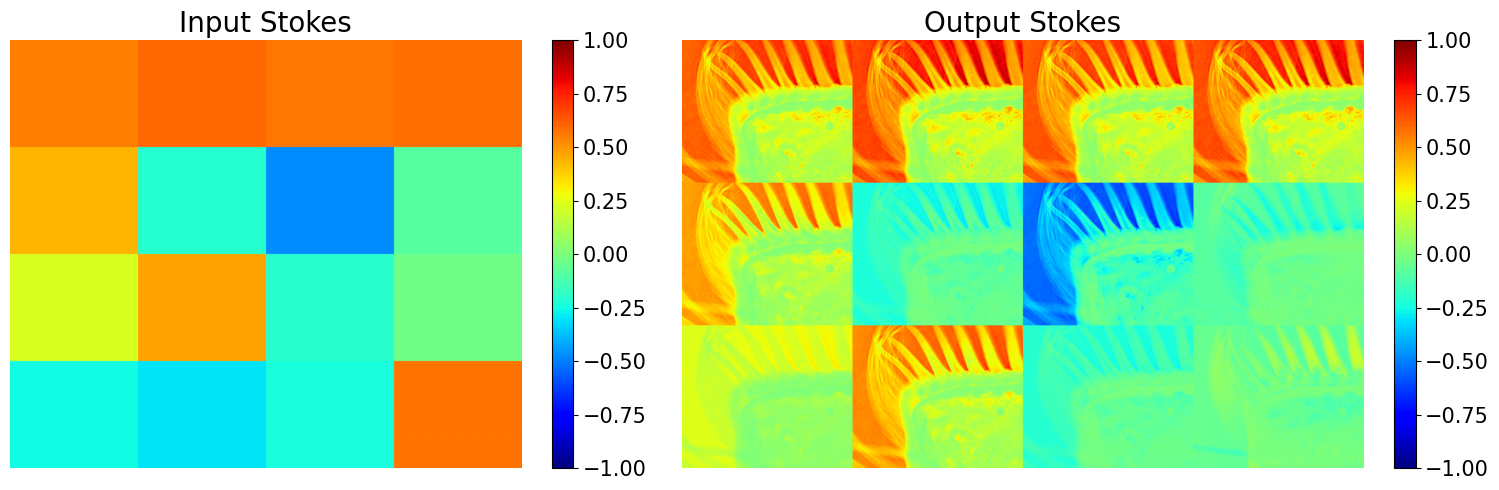

In [48]:
# Intercambiar para mostrar nomás
S_in[...,:,[0, 2]] = S_in[...,:,[2, 0]]
S_out[...,:,[0, 2]] = S_out[...,:,[2, 0]]

# Figuras
plt.figure(figsize=(17,5))

plt.subplot(1,2,1)
img = plt.imshow(acoplar_matriz(S_in)[:,:,1]/2**16, cmap='jet', vmin=-1, vmax=1)
cbar = plt.colorbar(img, fraction=0.046, pad=0.04)
cbar.ax.tick_params(labelsize=15)
plt.title('Input Stokes', fontsize=20)
plt.axis('off')

plt.subplot(1,2,2)
img = plt.imshow(acoplar_matriz(S_out)[:,:,1]/2**16, cmap='jet', vmin=-1, vmax=1)
cbar = plt.colorbar(img, fraction=0.046, pad=0.04)
cbar.ax.tick_params(labelsize=15)
plt.title('Output Stokes', fontsize=20)
plt.axis('off')

plt.tight_layout()
plt.show()

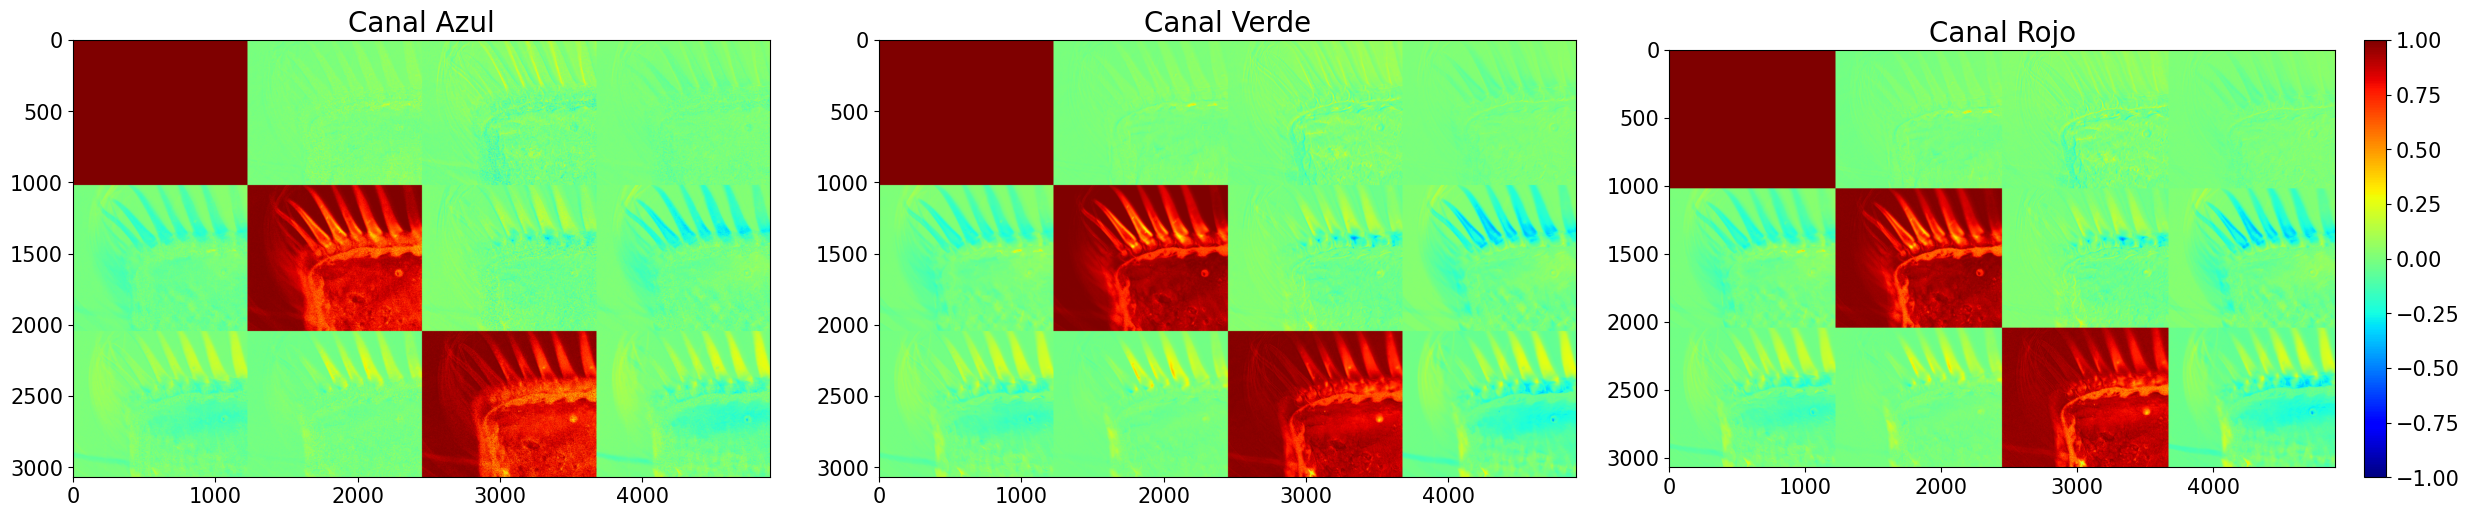

In [51]:
# Figura
plt.figure(figsize=(25,5))
canal_label = ['Azul', 'Verde', 'Rojo']

M_img = acoplar_matriz(M_norm)

for canal in range(3):
    ax = plt.subplot(1,3,canal+1)
    img = ax.imshow(M_img[:, :, canal], cmap='jet', vmin=-1, vmax=1)
    ax.set_title(f'Canal {canal_label[canal]}', fontsize=20)
    ax.tick_params(axis='both', labelsize=15)

# Colorbar común
cbar = plt.colorbar(img, fraction=0.046, pad=0.04)
cbar.ax.tick_params(labelsize=15)

plt.tight_layout()
plt.show()

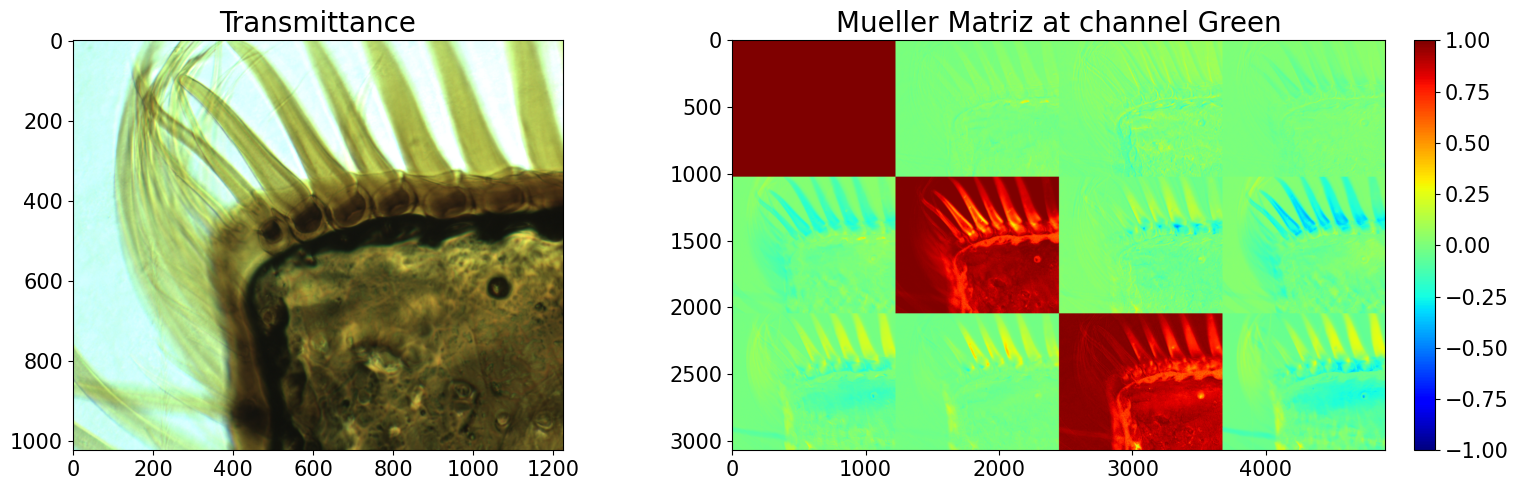

In [35]:
# Figura
plt.figure(figsize=(16,5))

canal = 1  # <-- elegís el canal
canal_label = ['Blue', 'Green', 'Red']

M_img = acoplar_matriz(M_norm)

m00_rgb = m00.copy()
m00_rgb[:,:,0] = m00[:,:,2]
m00_rgb[:,:,2] = m00[:,:,0]

# --- m00 ---
ax0 = plt.subplot(1,2,1)
img0 = ax0.imshow(m00_rgb, cmap='gray')
ax0.set_title('Transmittance', fontsize=20)
ax0.tick_params(axis='both', labelsize=15)

# --- canal elegido ---
ax1 = plt.subplot(1,2,2)
img1 = ax1.imshow(M_img[:, :, canal], cmap='jet', vmin=-1, vmax=1)
ax1.set_title(f'Mueller Matriz at channel {canal_label[canal]}', fontsize=20)
ax1.tick_params(axis='both', labelsize=15)

# Colorbar
cbar = plt.colorbar(img1, fraction=0.046, pad=0.04)
cbar.ax.tick_params(labelsize=15)

plt.tight_layout()
plt.show()

In [37]:
# Color
canal = 1

# Lu Chipman
MDelta, MR, MD, _ = lu_chipman_3x4(M_norm[:,:,canal,:,:])

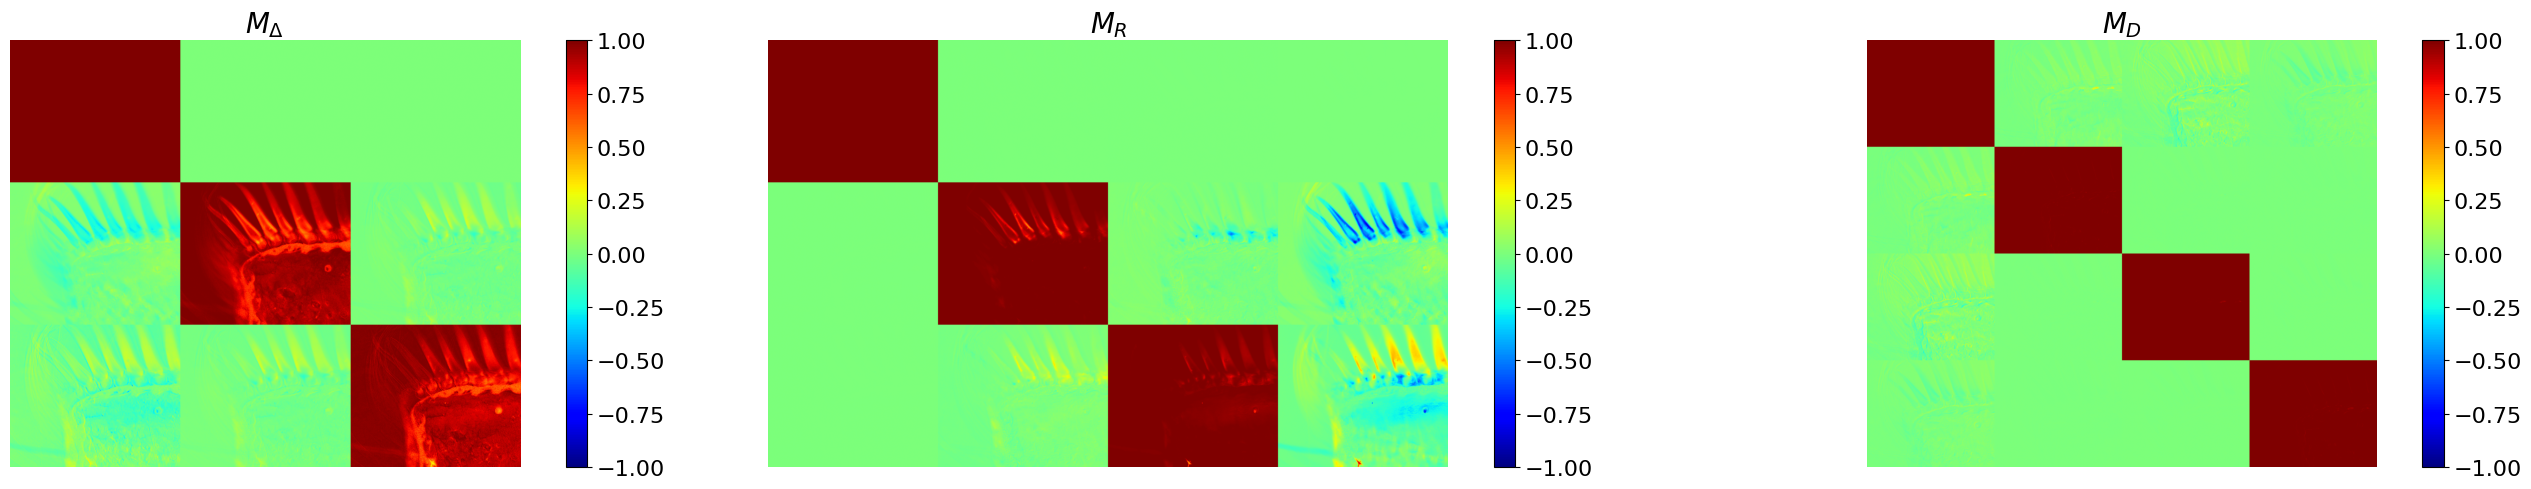

In [43]:
# Figuras
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(28,5))

im1 = ax1.imshow(acoplar_matriz(MDelta[:,:,np.newaxis,:,:]), cmap='jet', vmin=-1, vmax=1)
cbar1 = fig.colorbar(im1, ax=ax1)
cbar1.ax.tick_params(labelsize=16)
ax1.set_title(r'$M_{\Delta}$', fontsize=20)
ax1.axis('off')

im2 = ax2.imshow(acoplar_matriz(MR[:,:,np.newaxis,:,:]), cmap='jet', vmin=-1, vmax=1)
cbar2 = fig.colorbar(im2, ax=ax2)
cbar2.ax.tick_params(labelsize=16)
ax2.set_title(r'$M_{R}$', fontsize=20)
ax2.axis('off')

im3 = ax3.imshow(acoplar_matriz(MD[:,:,np.newaxis,:,:]), cmap='jet', vmin=-1, vmax=1)
cbar3 = fig.colorbar(im3, ax=ax3)
cbar3.ax.tick_params(labelsize=16)
ax3.set_title(r'$M_{D}$', fontsize=20)
ax3.axis('off')

plt.tight_layout()
plt.show()

In [38]:
# Propiedades polarimétricas
theta = np.degrees(optical_axis(MR))
delta = np.degrees(linear_retardance(MR))
Delta = power_of_depolarization(MDelta)
D = calcular_diatenuacion(MD)

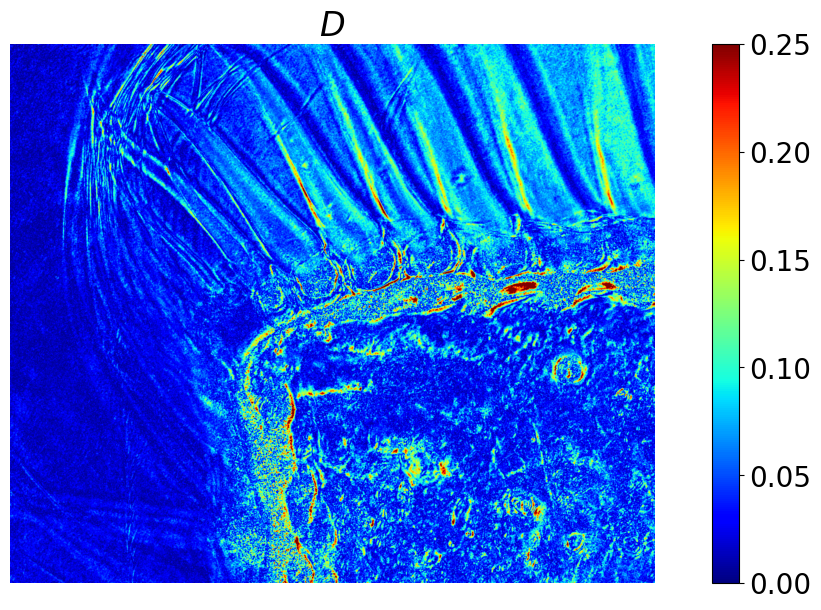

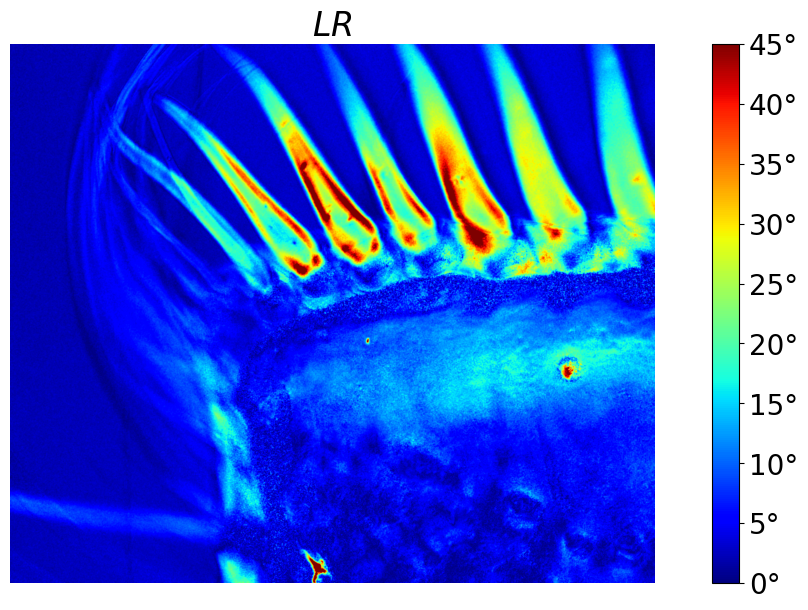

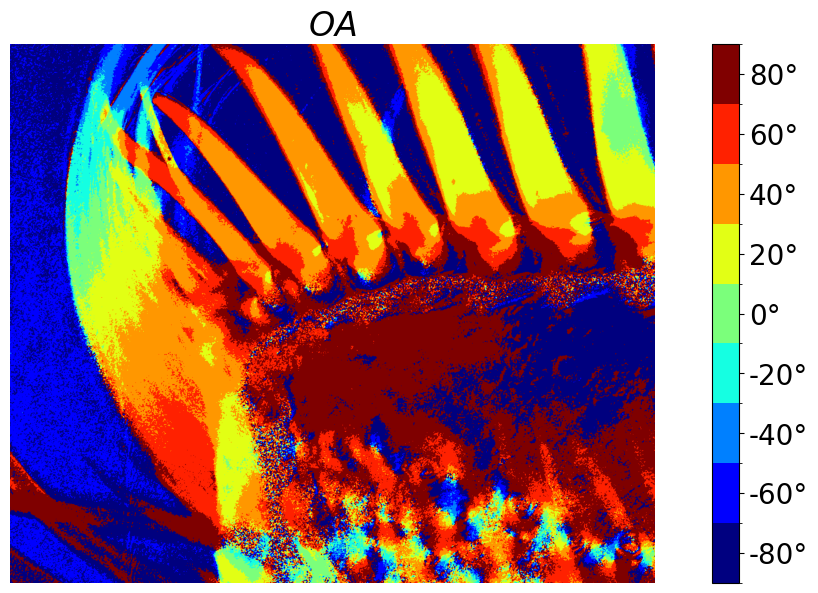

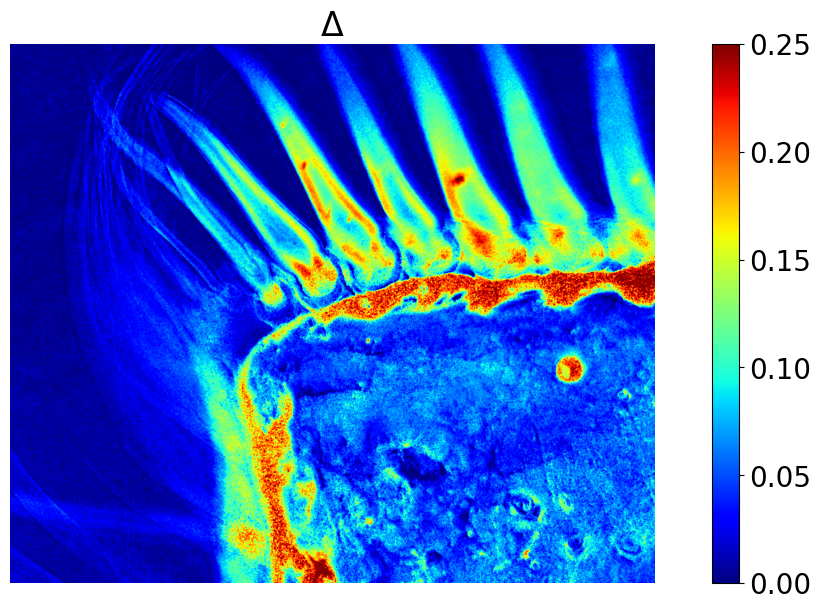

In [44]:
# Límites
D_max = 0.25
Delta_max = 0.25
LR_max = 45

# Diatenuación
plt.figure(figsize=(15, 7))
img = plt.imshow(D, cmap='jet', vmin=0, vmax=D_max)
plt.title(r'$D$', fontsize=24)
plt.axis('off')
cbar = plt.colorbar(img)
cbar.ax.tick_params(labelsize=20)

# Birrefringencia (Linear Retardance)
plt.figure(figsize=(15, 7))
img = plt.imshow(delta, cmap='jet', vmin=0, vmax=LR_max)
plt.title(r'$LR$', fontsize=24)
plt.axis('off')
cbar = plt.colorbar(img)
cbar.ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{int(x)}°'))
cbar.ax.tick_params(labelsize=20)

# Eje óptico
plt.figure(figsize=(15, 7))
limits = np.linspace(-90, 90, num=10)
cmap = plt.get_cmap('jet', len(limits) - 1)
norm = mcolors.BoundaryNorm(boundaries=limits, ncolors=len(limits)-1)
cmap.set_bad(color='black')
img = plt.imshow(theta, cmap=cmap, norm=norm)
plt.title(r'$OA$', fontsize=24)
ticks_mid = (limits[:-1] + limits[1:]) / 2
cbar = plt.colorbar(img, ticks=ticks_mid)
cbar.ax.set_yticklabels([f"{int(t)}°" for t in ticks_mid])
cbar.ax.tick_params(labelsize=20)
plt.axis('off')

# Depolarizancia
plt.figure(figsize=(15, 7))
img = plt.imshow(Delta, cmap='jet', vmin=0, vmax=Delta_max)
plt.title(r'$\Delta$', fontsize=24)
plt.axis('off')
cbar = plt.colorbar(img)
cbar.ax.tick_params(labelsize=20)

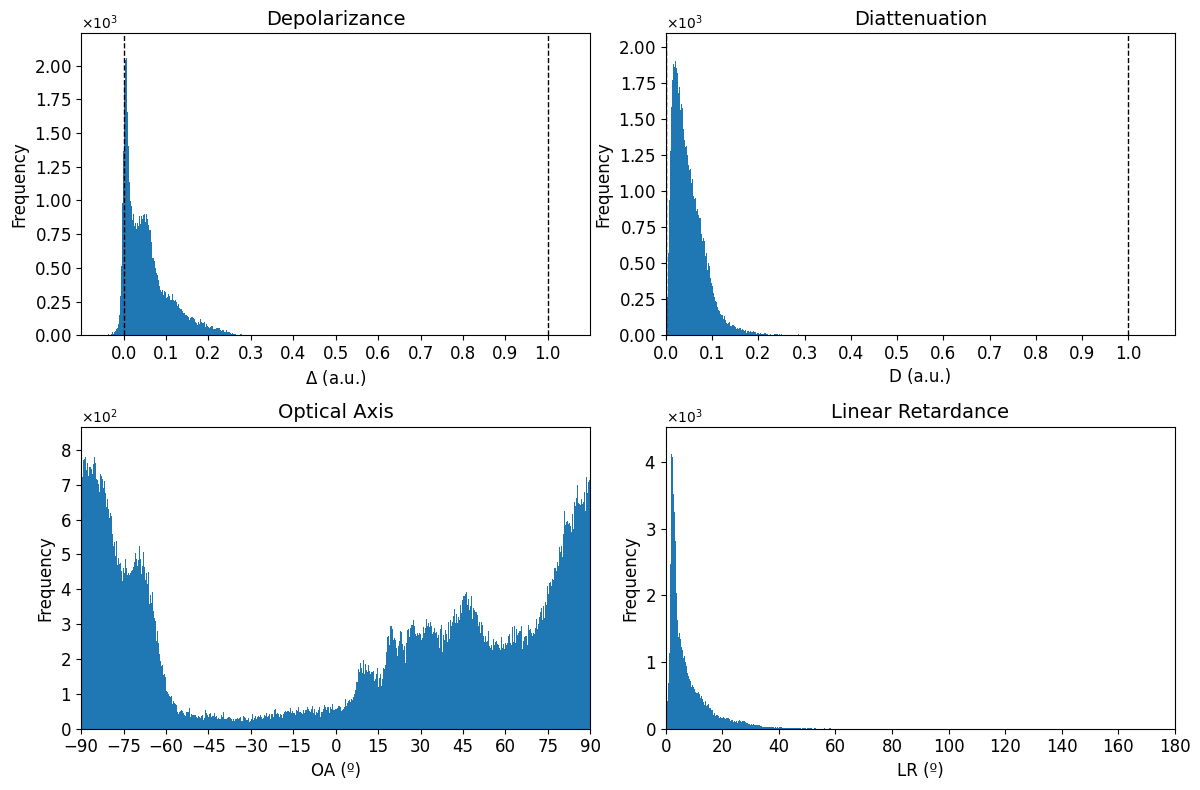

In [40]:
# Histogramas
fig, axs = plt.subplots(2, 2, figsize=(12,8))

variables = [Delta, D, theta, delta]
titulos = ['Depolarizance', 'Diattenuation', 'Optical Axis', 'Linear Retardance']
ejes = [r'$\Delta$ (a.u.)', 'D (a.u.)', 'OA (º)', 'LR (º)']

for ax, var, titulo, eje in zip(axs.ravel(), variables, titulos, ejes):

    var_flat = var.flatten()
    ax.hist(var_flat, bins=5000)

    # 🔥 Límites en X según variable
    if titulo == 'Depolarizance':
        ax.set_xlim(-0.1, 1.1)
        ax.axvline(0, color='black', linestyle='--', linewidth=1)
        ax.axvline(1, color='black', linestyle='--', linewidth=1)
        ax.set_xticks(np.arange(0, 1.05, 0.1))

    elif titulo == 'Diattenuation':
        ax.set_xlim(0, 1.1)
        ax.axvline(0, color='black', linestyle='--', linewidth=1)
        ax.axvline(1, color='black', linestyle='--', linewidth=1)
        ax.set_xticks(np.arange(0, 1.05, 0.1))

    elif titulo == 'Linear Retardance':
        ax.set_xlim(0, 180)
        ax.set_xticks(np.arange(0, 181, 20))

    elif titulo == 'Optical Axis':
        ax.set_xlim(-90, 90)
        ax.set_xticks(np.arange(-90, 91, 15))

    # Labels y estilo
    ax.set_title(titulo, fontsize=14)
    ax.set_xlabel(eje, fontsize=12)
    ax.set_ylabel('Frequency', fontsize=12)
    ax.tick_params(axis='both', labelsize=12)

    # Notación científica en Y
    ax.yaxis.set_major_formatter(ticker.ScalarFormatter(useMathText=True))
    ax.ticklabel_format(axis='y', style='sci', scilimits=(0,0))

plt.tight_layout()
plt.show()